In [ ]:
import requests
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
# --- CONFIGURATION ---
# ELEXON_API_KEY = ""
# DAYS_BACK = 30


In [ ]:

def get_market_data(days=30):
    """Fetches UK Electricity Imbalance Prices from Elexon."""
    # Using the B1770 report for Imbalance Prices
    url = f"https://api.bmreports.com/BMRS/B1770/v1?APIKey={ELEXON_API_KEY}&ServiceType=csv"
    # Note: In a real app, loop through dates. This is a conceptual fetch.
    print("Fetching Elexon Electricity Prices...")
    # For 2026, Elexon's 'Insights' API is the preferred endpoint.
    return pd.DataFrame() # Placeholder for the CSV result

def get_weather(lat, lon, label, days=30):
    """Fetches historical and forecast weather from Open-Meteo."""
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "temperature_2m,windspeed_100m,cloudcover",
        "past_days": days,
        "forecast_days": 2,
        "timezone": "Europe/London"
    }
    r = requests.get(url, params=params).json()
    df = pd.DataFrame(r['hourly'])
    df['time'] = pd.to_datetime(df['time'])
    # Rename columns to identify location (e.g., 'london_temp')
    df.columns = ['time'] + [f"{label}_{c}" for c in df.columns if c != 'time']
    return df

def get_commodities(days=30):
    """Fetches Gas and Oil prices from Yahoo Finance."""
    print("Fetching Commodity Prices (Gas & Oil)...")
    # Natural Gas (NBP/UK) is usually 'NF=F' or 'TTF=F' for EU benchmark
    gas = yf.Ticker("TTF=F").history(period=f"{days}d")
    oil = yf.Ticker("BZ=F").history(period=f"{days}d") # Brent Crude
    return gas, oil


In [2]:
BASE_URL = "https://api.bmreports.com/insights/v1" # Standard 2026 endpoint

def get_elexon_data(endpoint, params):
    """Generic fetch for Elexon Insights APIs"""
    response = requests.get(f"{BASE_URL}{endpoint}", params=params)
    if response.status_code == 200:
        # Most of these return JSON by default now
        data = response.json()
        return pd.DataFrame(data)
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None

# Example: Fetching System Prices for a specific date
# In 2026, the API usually expects YYYY-MM-DD
params = {"settlementDate": "2026-03-23"}
prices_df = get_elexon_data("/balancing/settlement/system-prices", params)

# Example: Fetching Wind Generation Forecasts
wind_df = get_elexon_data("/forecast/generation/wind", params)

print("Sample Price Data:")
print(prices_df.head())

ConnectTimeout: HTTPSConnectionPool(host='api.bmreports.com', port=443): Max retries exceeded with url: /insights/v1/balancing/settlement/system-prices?settlementDate=2026-03-23 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x0000019D4E9239E0>, 'Connection to api.bmreports.com timed out. (connect timeout=None)'))

In [ ]:
def get_elexon_dataset(dataset_name, start_time, end_time):
    """
    Fetches time-series data from Elexon's /datasets/ endpoint.
    Times must be in ISO 8601 format, e.g., 'YYYY-MM-DDTHH:MMZ'
    """
    url = f"https://data.elexon.co.uk/bmrs/api/v1/datasets/{dataset_name}"
    
    params = {
        "from": start_time,
        "to": end_time,
        "format": "json" 
    }
    
    print(f"Fetching {dataset_name} from {start_time} to {end_time}...")
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        data = response.json()
        if 'data' in data:
            df = pd.DataFrame(data['data'])
            # Convert the string timestamps to actual datetime objects
            if 'startTime' in df.columns:
                df['startTime'] = pd.to_datetime(df['startTime'])
            return df
        else:
            return pd.DataFrame()
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None



In [ ]:

start = "2026-03-20T00:00Z"
end = "2026-03-23T00:00Z"

mid_df = get_elexon_dataset("MID", start, end)

if mid_df is not None and not mid_df.empty:
    print("\n--- Market Index Data (MID) ---")
    print(mid_df[['startTime', 'dataProvider', 'settlementPeriod', 'price', 'volume']].head())

Fetching MID from 2026-03-20T00:00Z to 2026-03-23T00:00Z...

--- Market Index Data (MID) ---
                  startTime dataProvider  settlementPeriod   price   volume
0 2026-03-23 00:00:00+00:00      APXMIDP                 1  129.24  1335.05
1 2026-03-23 00:00:00+00:00     N2EXMIDP                 1    0.00     0.00
2 2026-03-22 23:30:00+00:00      APXMIDP                48  126.26  1429.20
3 2026-03-22 23:30:00+00:00     N2EXMIDP                48    0.00     0.00
4 2026-03-22 23:00:00+00:00      APXMIDP                47  127.11  1739.40


<Axes: ylabel='price'>

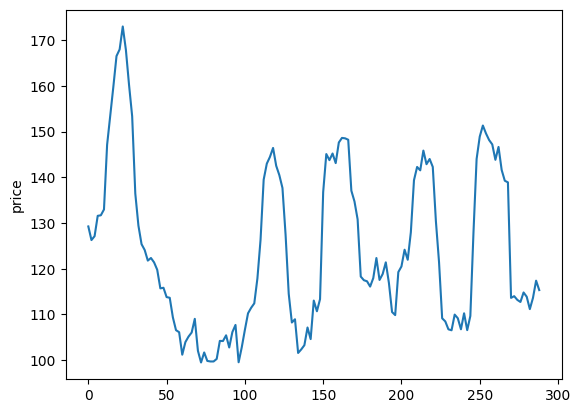

In [8]:
import seaborn as sns
sns.lineplot(mid_df.loc[mid_df['dataProvider']=='APXMIDP','price'])

In [71]:
from datetime import datetime, timedelta, timezone
end_date = datetime(2026, 3, 1, tzinfo=timezone.utc)
print(end_date)
start_date = end_date - timedelta(days=365*4)
print(start_date)
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')


2026-03-01 00:00:00+00:00
2022-03-02 00:00:00+00:00


datetime.datetime(2026, 3, 23, 0, 0, tzinfo=datetime.timezone.utc)

In [67]:
import requests
import pandas as pd

def get_elexon_dataset(dataset_name, start_time, end_time):
    """Fetches a specific time window from Elexon."""
    url = f"https://data.elexon.co.uk/bmrs/api/v1/datasets/{dataset_name}"
    params = {"from": start_time, "to": end_time, "format": "json"}
    
    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        if 'data' in data and data['data']:
            return pd.DataFrame(data['data'])
    else:
        print(f"Error {response.status_code}: {response.text}")
    return pd.DataFrame() # Return empty DF on failure

def fetch_month_of_data(dataset_name,start_date,end_date):
    """Loops through the last 30 days in 7-day chunks."""
    # Set our end date to today (March 24, 2026) and start date 30 days ago
    # end_date = datetime.now(timezone.utc)
    # start_date = end_date - timedelta(days=365)
    
    current_start = start_date
    all_chunks = []
    
    print(f"--- Fetching 1 Month of {dataset_name} Data ---")
    
    while current_start < end_date:
        # Move forward by 7 days, but don't go past the final end_date
        current_end = min(current_start + timedelta(days=7), end_date)
        
        # Format dates to exactly match Elexon's requirement: YYYY-MM-DDTHH:MMZ
        start_str = current_start.strftime('%Y-%m-%dT%H:%MZ')
        end_str = current_end.strftime('%Y-%m-%dT%H:%MZ')
        
        print(f"Fetching chunk: {start_str} to {end_str}")
        chunk_df = get_elexon_dataset(dataset_name, start_str, end_str)
        
        if not chunk_df.empty:
            all_chunks.append(chunk_df)
            
        # Step forward for the next loop
        current_start = current_end
        
    # Combine all the weekly chunks into one massive DataFrame
    if all_chunks:
        master_df = pd.concat(all_chunks, ignore_index=True)
        
        # Clean up the timestamps and sort chronologically
        if 'startTime' in master_df.columns:
            master_df['startTime'] = pd.to_datetime(master_df['startTime'])
            master_df = master_df.sort_values('startTime').reset_index(drop=True)
            
        return master_df
    else:
        print("No data was fetched.")
        return pd.DataFrame()

# --- Execution ---
# Let's grab 1 month of Market Index Data (MID)
monthly_mid_df = fetch_month_of_data("MID", start_date, end_date)

if not monthly_mid_df.empty:
    print("\n✅ Success! Total rows fetched:", len(monthly_mid_df))
    print(monthly_mid_df[['startTime', 'dataProvider', 'settlementPeriod', 'price']].head())

--- Fetching 1 Month of MID Data ---
Fetching chunk: 2018-03-03T00:00Z to 2018-03-10T00:00Z
Fetching chunk: 2018-03-10T00:00Z to 2018-03-17T00:00Z
Fetching chunk: 2018-03-17T00:00Z to 2018-03-24T00:00Z
Fetching chunk: 2018-03-24T00:00Z to 2018-03-31T00:00Z
Fetching chunk: 2018-03-31T00:00Z to 2018-04-07T00:00Z
Fetching chunk: 2018-04-07T00:00Z to 2018-04-14T00:00Z
Fetching chunk: 2018-04-14T00:00Z to 2018-04-21T00:00Z
Fetching chunk: 2018-04-21T00:00Z to 2018-04-28T00:00Z
Fetching chunk: 2018-04-28T00:00Z to 2018-05-05T00:00Z
Fetching chunk: 2018-05-05T00:00Z to 2018-05-12T00:00Z
Fetching chunk: 2018-05-12T00:00Z to 2018-05-19T00:00Z
Fetching chunk: 2018-05-19T00:00Z to 2018-05-26T00:00Z
Fetching chunk: 2018-05-26T00:00Z to 2018-06-02T00:00Z
Fetching chunk: 2018-06-02T00:00Z to 2018-06-09T00:00Z
Fetching chunk: 2018-06-09T00:00Z to 2018-06-16T00:00Z
Fetching chunk: 2018-06-16T00:00Z to 2018-06-23T00:00Z
Fetching chunk: 2018-06-23T00:00Z to 2018-06-30T00:00Z
Fetching chunk: 2018-06-30T0

In [68]:
monthly_mid_df

,dataset,startTime,dataProvider,settlementDate,settlementPeriod,price,volume
0,MID,2018-03-03 00:00:00+00:00,N2EXMIDP,2018-03-03,1,0.00,0.00
1,MID,2018-03-03 00:00:00+00:00,APXMIDP,2018-03-03,1,56.35,725.20
2,MID,2018-03-03 00:30:00+00:00,APXMIDP,2018-03-03,2,60.11,650.40
3,MID,2018-03-03 00:30:00+00:00,N2EXMIDP,2018-03-03,2,0.00,0.00
4,MID,2018-03-03 01:00:00+00:00,APXMIDP,2018-03-03,3,96.48,673.80
...,...,...,...,...,...,...,...
275805,MID,2026-02-28 23:00:00+00:00,APXMIDP,2026-02-28,47,89.46,2607.10
275806,MID,2026-02-28 23:30:00+00:00,N2EXMIDP,2026-02-28,48,0.00,0.00
275807,MID,2026-02-28 23:30:00+00:00,APXMIDP,2026-02-28,48,89.33,2137.65
275808,MID,2026-03-01 00:00:00+00:00,N2EXMIDP,2026-03-01,1,0.00,0.00


<Axes: ylabel='price'>

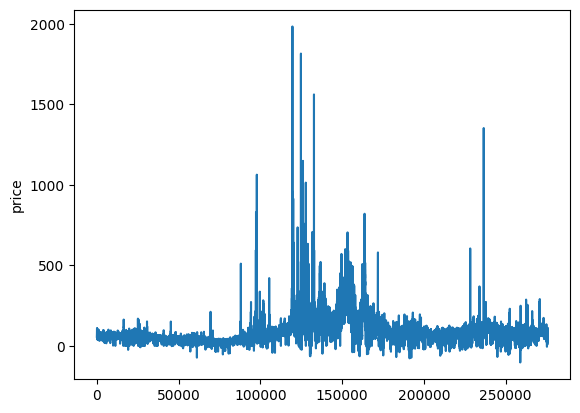

In [69]:
sns.lineplot(monthly_mid_df.loc[monthly_mid_df['dataProvider']=='APXMIDP','price'])

<Axes: ylabel='price'>

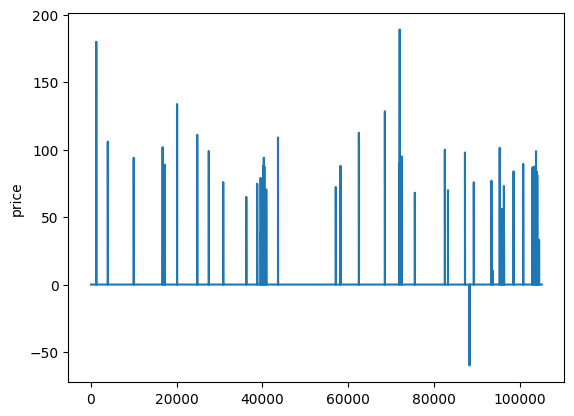

In [15]:
sns.lineplot(monthly_mid_df.loc[monthly_mid_df['dataProvider']=='N2EXMIDP','price'])

In [70]:
monthly_mid_df=monthly_mid_df.loc[monthly_mid_df['dataProvider']=='APXMIDP']
monthly_mid_df

,dataset,startTime,dataProvider,settlementDate,settlementPeriod,price,volume
1,MID,2018-03-03 00:00:00+00:00,APXMIDP,2018-03-03,1,56.35,725.20
2,MID,2018-03-03 00:30:00+00:00,APXMIDP,2018-03-03,2,60.11,650.40
4,MID,2018-03-03 01:00:00+00:00,APXMIDP,2018-03-03,3,96.48,673.80
6,MID,2018-03-03 01:30:00+00:00,APXMIDP,2018-03-03,4,65.56,718.00
8,MID,2018-03-03 02:00:00+00:00,APXMIDP,2018-03-03,5,59.93,515.50
...,...,...,...,...,...,...,...
275801,MID,2026-02-28 22:00:00+00:00,APXMIDP,2026-02-28,45,90.83,2331.40
275802,MID,2026-02-28 22:30:00+00:00,APXMIDP,2026-02-28,46,88.31,2552.95
275805,MID,2026-02-28 23:00:00+00:00,APXMIDP,2026-02-28,47,89.46,2607.10
275807,MID,2026-02-28 23:30:00+00:00,APXMIDP,2026-02-28,48,89.33,2137.65


In [ ]:

def fetch_weather_month(lat, lon, location_name,start_str, end_str):
    """
    Fetches historical hourly weather data for a specific location.
    Using the Open-Meteo Archive API for exact historical dates.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_str,
        "end_date": end_str,
        "hourly": "temperature_2m,wind_speed_100m,cloud_cover",
        "timezone": "UTC" # Keep everything in UTC to match Elexon!
    }
    
    print(f"Fetching {location_name} Weather: {start_str} to {end_str}...")
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        data = response.json()
        df = pd.DataFrame(data['hourly'])
        # Rename columns so we know which location they belong to
        df = df.rename(columns={
            "temperature_2m": f"{location_name}_temp",
            "wind_speed_100m": f"{location_name}_wind",
            "cloud_cover": f"{location_name}_clouds"
        })
        df['time'] = pd.to_datetime(df['time'])
        return df
    else:
        print(f"Error {response.status_code}: {response.text}")
        return pd.DataFrame()



london_weather = fetch_weather_month(51.5074, -0.1278, "london",start_str, end_str)
north_sea_weather = fetch_weather_month(54.73, 1.68, "north_sea",start_str, end_str)
scottish_highlands_weather = fetch_weather_month(57.1, -4.0, "Scottish Highlands",start_str, end_str)
Cornwall_weather = fetch_weather_month(50.2, -5.0, "Cornwall",start_str, end_str)
weather_df = pd.merge(london_weather, north_sea_weather, on="time", how="inner")
weather_df = pd.merge(weather_df,scottish_highlands_weather, on="time", how="inner")
weather_df = pd.merge(weather_df,Cornwall_weather, on="time", how="inner")
weather_df


Fetching london Weather: 2023-03-02 to 2026-03-01...
Fetching north_sea Weather: 2023-03-02 to 2026-03-01...
Fetching Scottish Highlands Weather: 2023-03-02 to 2026-03-01...
Fetching Cornwall Weather: 2023-03-02 to 2026-03-01...


,time,london_temp,london_wind,london_clouds,north_sea_temp,north_sea_wind,north_sea_clouds,Scottish Highlands_temp,Scottish Highlands_wind,Scottish Highlands_clouds,Cornwall_temp,Cornwall_wind,Cornwall_clouds
0,2023-03-02 00:00:00,2.5,25.3,30,6.3,17.9,100,2.1,22.3,100,5.7,23.2,57
1,2023-03-02 01:00:00,1.4,23.7,0,6.3,16.5,95,2.2,20.8,100,4.7,25.5,38
2,2023-03-02 02:00:00,0.9,24.5,1,6.3,14.9,100,2.6,18.2,100,4.2,25.5,22
3,2023-03-02 03:00:00,0.8,25.7,5,6.2,13.7,100,2.9,20.4,100,3.7,24.2,14
4,2023-03-02 04:00:00,0.6,26.3,2,6.1,14.5,100,2.9,21.8,86,3.2,23.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2026-03-01 19:00:00,10.8,29.5,100,8.1,51.8,20,8.3,42.1,100,10.6,52.7,100
26300,2026-03-01 20:00:00,10.9,31.4,100,8.1,53.4,71,8.4,43.3,100,10.4,55.4,100
26301,2026-03-01 21:00:00,10.8,32.7,100,8.4,57.0,85,8.3,44.9,100,10.4,55.7,100
26302,2026-03-01 22:00:00,10.7,32.4,100,8.5,58.1,59,7.9,44.2,100,10.4,53.9,100


In [ ]:
import numpy as np

# Define UK Bounding Box
lat_range = np.linspace(49.0, 60.0, 25) 
lon_range = np.linspace(-9.0, 2.0, 25) 

grid_dfs = []
for lat in lat_range:
    for lon in lon_range:
        # Create a unique name for each grid cell
        cell_name = f"grid_{round(lat,1)}_{round(lon,1)}"
        df = fetch_weather_month(lat, lon, cell_name, start_str, end_str)
        grid_dfs.append(df)

# Merge all (This will create a very wide DataFrame)
final_grid_df = grid_dfs[0]
for next_df in grid_dfs[1:]:
    final_grid_df = pd.merge(final_grid_df, next_df, on="time", how="inner")

Fetching grid_49.0_-9.0 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-8.5 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-8.1 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-7.6 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-7.2 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-6.7 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-6.2 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-5.8 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-5.3 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-4.9 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-4.4 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-4.0 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-3.5 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-3.0 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-2.6 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-2.1 Weather: 2023-03-02 to 2026-03-01...
Fetching grid_49.0_-1.7 

KeyboardInterrupt: 

In [56]:
pip install retry-requests


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
from datetime import datetime, timedelta, timezone
end_date = datetime(2026, 3, 1, tzinfo=timezone.utc)
print(end_date)
start_date = end_date - timedelta(days=365*4)
print(start_date)
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

2026-03-01 00:00:00+00:00
2022-03-02 00:00:00+00:00


In [76]:
np.linspace(49.0, 60.0, 25)

array([49.        , 49.45833333, 49.91666667, 50.375     , 50.83333333,
       51.29166667, 51.75      , 52.20833333, 52.66666667, 53.125     ,
       53.58333333, 54.04166667, 54.5       , 54.95833333, 55.41666667,
       55.875     , 56.33333333, 56.79166667, 57.25      , 57.70833333,
       58.16666667, 58.625     , 59.08333333, 59.54166667, 60.        ])

In [ ]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

# # Setup the API client with a cache and retry on error
# cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
# retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
# openmeteo = openmeteo_requests.Client(session=retry_session)

# # You can pass LISTS of latitudes and longitudes in ONE call
# params = {
#     "latitude":  np.linspace(49.0, 60.0, 25),
#       # Add all your grid lats here
#     "longitude": np.linspace(-9.0, 2.0, 25), # Add all your grid lons here
#     "start_date": start_str,
#     "end_date": end_str,
#     "hourly": ["temperature_2m", "wind_speed_100m", "cloud_cover"]
# }
# responses = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)

In [ ]:
# import pandas as pd

# all_locations_data = []

# for i, response in enumerate(responses):
#     # Get hourly data object
#     hourly = response.Hourly()
    
#     # Get the time range
#     # Open-Meteo provides start/end/interval in seconds
#     time = pd.date_range(
#         start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
#         end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
#         freq=pd.Timedelta(seconds=hourly.Interval()),
#         inclusive="left"
#     )

#     # Extract the variables
#     data = {
#         "time": time,
#         f"temp_loc_{i}": hourly.Variables(0).ValuesAsNumpy(),
#         f"wind_loc_{i}": hourly.Variables(1).ValuesAsNumpy(),
#         f"clouds_loc_{i}": hourly.Variables(2).ValuesAsNumpy()
#     }
    
#     all_locations_data.append(pd.DataFrame(data).set_index("time"))

# # Combine all locations into one wide dataframe
# final_df = pd.concat(all_locations_data, axis=1)
# print(final_df.head())

                           temp_loc_0  wind_loc_0  clouds_loc_0  temp_loc_1  \
time                                                                          
2022-03-02 00:00:00+00:00       10.55   28.856194         100.0       10.30   
2022-03-02 01:00:00+00:00       10.45   23.110207         100.0       10.55   
2022-03-02 02:00:00+00:00       10.45   21.533897         100.0       10.55   
2022-03-02 03:00:00+00:00       10.50   26.785547         100.0       10.45   
2022-03-02 04:00:00+00:00       10.50   29.827904         100.0       10.25   

                           wind_loc_1  clouds_loc_1  temp_loc_2  wind_loc_2  \
time                                                                          
2022-03-02 00:00:00+00:00   29.257614         100.0       10.55   33.971867   
2022-03-02 01:00:00+00:00   26.339109         100.0       10.40   26.574244   
2022-03-02 02:00:00+00:00   24.014996         100.0       10.35   17.253731   
2022-03-02 03:00:00+00:00   25.964960         100.0

In [ ]:
import numpy as np
import itertools
import openmeteo_requests
import requests_cache
from retry_requests import retry
import pandas as pd
lats = np.linspace(49.0, 60.0, 8) 
lons = np.linspace(-9.0, 2.0, 8)  

# 2. Create the true 5x5 grid (all 25 combinations)
# This creates points going row by row, from top-left to bottom-right
grid_points = list(itertools.product(lats, lons))

# 3. Unpack into separate lists for the API
api_lats = [point[0] for point in grid_points]
api_lons = [point[1] for point in grid_points]

# Check that we have exactly 25 points
print(f"Fetching {len(api_lats)} grid locations...")

# Setup the API client with a cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

params = {
    "latitude": api_lats,    # Our 25 gridded latitudes
    "longitude": api_lons,   # Our 25 gridded longitudes
    "start_date": start_str,
    "end_date": end_str,
    "hourly": ["temperature_2m", "wind_speed_100m", "cloud_cover"]
}

responses = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)


Fetching 64 grid locations...


In [ ]:

all_locations_data = []

for i, response in enumerate(responses):
    hourly = response.Hourly()
    
    time = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    )

    data = {
        "time": time,
        f"temp_loc_{i}": hourly.Variables(0).ValuesAsNumpy(),
        f"wind_loc_{i}": hourly.Variables(1).ValuesAsNumpy(),
        f"clouds_loc_{i}": hourly.Variables(2).ValuesAsNumpy()
    }
    
    all_locations_data.append(pd.DataFrame(data).set_index("time"))

final_df = pd.concat(all_locations_data, axis=1)
final_df = final_df.reset_index() 
print("Shape of final_df:", final_df.shape) 

Shape of final_df: (35064, 193)


In [81]:
final_df

,time,temp_loc_0,wind_loc_0,clouds_loc_0,temp_loc_1,wind_loc_1,clouds_loc_1,temp_loc_2,wind_loc_2,clouds_loc_2,...,clouds_loc_60,temp_loc_61,wind_loc_61,clouds_loc_61,temp_loc_62,wind_loc_62,clouds_loc_62,temp_loc_63,wind_loc_63,clouds_loc_63
0,2022-03-02 00:00:00+00:00,10.55,28.856194,100.0,11.05,20.771093,100.0,11.45,49.795948,100.0,...,72.0,6.536500,36.546650,67.0,7.40,38.593948,87.0,7.35,36.764088,72.0
1,2022-03-02 01:00:00+00:00,10.45,23.110207,100.0,10.95,11.275530,100.0,11.40,46.634941,100.0,...,6.0,6.386500,32.385994,98.0,7.35,37.567860,19.0,7.35,35.786968,3.0
2,2022-03-02 02:00:00+00:00,10.45,21.533897,100.0,10.80,10.041354,100.0,11.40,43.237484,100.0,...,100.0,6.286500,29.308508,40.0,7.30,36.500519,77.0,7.30,35.097691,10.0
3,2022-03-02 03:00:00+00:00,10.50,26.785547,100.0,10.65,16.099689,100.0,11.25,42.554680,100.0,...,100.0,6.086500,27.859905,100.0,7.25,33.563122,100.0,7.25,36.939926,24.0
4,2022-03-02 04:00:00+00:00,10.50,29.827904,100.0,10.55,34.619946,100.0,11.05,44.316570,98.0,...,100.0,5.986500,23.113008,100.0,7.25,28.745949,99.0,7.25,36.290424,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2026-03-01 19:00:00+00:00,12.10,77.890717,100.0,11.85,73.789024,100.0,11.70,66.718117,100.0,...,100.0,7.336500,50.572311,100.0,7.20,53.110981,100.0,6.80,54.420761,100.0
35060,2026-03-01 20:00:00+00:00,12.15,79.247444,100.0,11.90,73.189873,100.0,11.75,64.880943,100.0,...,100.0,7.536500,48.099083,100.0,7.20,56.288216,100.0,6.95,53.026730,100.0
35061,2026-03-01 21:00:00+00:00,12.20,78.863007,100.0,11.95,73.052727,100.0,11.85,67.342613,100.0,...,100.0,7.636500,45.617840,100.0,7.30,55.100582,100.0,6.95,56.926971,100.0
35062,2026-03-01 22:00:00+00:00,10.95,39.377647,100.0,12.10,72.740707,100.0,11.85,66.122749,100.0,...,100.0,7.886500,51.348927,100.0,7.50,56.125660,100.0,7.00,58.300549,100.0


In [82]:
final_df.to_csv('grid_weather_8x8_2023-2026.csv', index=True)

In [63]:
final_df.to_csv('grid_weather_25x25_2023-2026.csv', index=True)

In [ ]:
def fetch_commodities_month(start_str, end_str):
    """Fetches daily Gas (Dutch TTF) and Oil (Brent) prices."""
    print(f"Fetching Commodity Prices: {start_str} to {end_str}...")
    
    tickers = ["TTF=F", "BZ=F"]
    
    yf_end = (end_date + timedelta(days=1)).strftime('%Y-%m-%d')
    
    df = yf.download(tickers, start=start_str, end=yf_end, progress=False)
    
    if 'Close' in df.columns:
        close_df = df['Close'].reset_index()
    else:
        # in case of some yfinance version differences
        close_df = df.xs('Close', axis=1, level=0).reset_index() if isinstance(df.columns, pd.MultiIndex) else df.reset_index()
        
    close_df = close_df.rename(columns={"TTF=F": "gas_price", "BZ=F": "oil_price", "Date": "time"})
    
    #  UTC datetime
    close_df['time'] = pd.to_datetime(close_df['time']).dt.tz_localize('UTC')
    return close_df
commodities_df = fetch_commodities_month(start_str, end_str)

Fetching Commodity Prices: 2023-03-02 to 2026-03-01...


C:\Users\steph\AppData\Local\Temp\ipykernel_23404\1681294246.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start_str, end=yf_end, progress=False)


In [19]:
commodities_df

Ticker,time,oil_price,gas_price
0,2023-03-02 00:00:00+00:00,84.750000,46.814999
1,2023-03-03 00:00:00+00:00,85.830002,44.980000
2,2023-03-06 00:00:00+00:00,86.180000,42.148998
3,2023-03-07 00:00:00+00:00,83.290001,43.369999
4,2023-03-08 00:00:00+00:00,82.660004,42.339001
...,...,...,...
749,2026-02-23 00:00:00+00:00,71.489998,31.834000
750,2026-02-24 00:00:00+00:00,70.769997,30.891001
751,2026-02-25 00:00:00+00:00,70.849998,31.049999
752,2026-02-26 00:00:00+00:00,70.750000,32.223999


In [61]:
weather_df

,time,london_temp,london_wind,london_clouds,north_sea_temp,north_sea_wind,north_sea_clouds,Scottish Highlands_temp,Scottish Highlands_wind,Scottish Highlands_clouds,Cornwall_temp,Cornwall_wind,Cornwall_clouds
0,2023-03-02 00:00:00,2.5,25.3,30,6.3,17.9,100,2.1,22.3,100,5.7,23.2,57
1,2023-03-02 01:00:00,1.4,23.7,0,6.3,16.5,95,2.2,20.8,100,4.7,25.5,38
2,2023-03-02 02:00:00,0.9,24.5,1,6.3,14.9,100,2.6,18.2,100,4.2,25.5,22
3,2023-03-02 03:00:00,0.8,25.7,5,6.2,13.7,100,2.9,20.4,100,3.7,24.2,14
4,2023-03-02 04:00:00,0.6,26.3,2,6.1,14.5,100,2.9,21.8,86,3.2,23.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2026-03-01 19:00:00,10.8,29.5,100,8.1,51.8,20,8.3,42.1,100,10.6,52.7,100
26300,2026-03-01 20:00:00,10.9,31.4,100,8.1,53.4,71,8.4,43.3,100,10.4,55.4,100
26301,2026-03-01 21:00:00,10.8,32.7,100,8.4,57.0,85,8.3,44.9,100,10.4,55.7,100
26302,2026-03-01 22:00:00,10.7,32.4,100,8.5,58.1,59,7.9,44.2,100,10.4,53.9,100


In [ ]:
mid_clean = monthly_mid_df.groupby('startTime')[['price', 'volume']].mean().reset_index()

# enforce UTC timezone 
mid_clean = mid_clean.rename(columns={'startTime': 'time'})
mid_clean['time'] = pd.to_datetime(mid_clean['time'], utc=True)
mid_clean.set_index('time', inplace=True)

weather_clean = weather_df[['time', 'london_temp','london_wind', 'london_clouds', 'north_sea_wind','Scottish Highlands_wind','Cornwall_clouds']].copy()
weather_clean['time'] = pd.to_datetime(weather_clean['time'], utc=True)
weather_clean.set_index('time', inplace=True)

# Resample from 60 mins to 30 mins using Linear Interpolation
weather_resampled = weather_clean.resample('30min').interpolate(method='linear')

commodities_clean = commodities_df.copy()
commodities_clean['time'] = pd.to_datetime(commodities_clean['time'], utc=True)
commodities_clean.set_index('time', inplace=True)


commodities_resampled = commodities_clean.resample('30min').ffill()


master_df = mid_clean.join(weather_resampled, how='left') \
                     .join(commodities_resampled, how='left')

# Forward fill any initial NaNs (e.g., if the first day was a weekend)
master_df = master_df.ffill().dropna()

print("\n✅ Master Transformer Dataset:")
print(master_df.head())
print(f"\nShape: {master_df.shape} (Rows, Features)")


✅ Master Transformer Dataset:
                            price   volume  london_temp  london_wind  \
time                                                                   
2023-03-02 00:00:00+00:00  53.500  363.125         2.50         25.3   
2023-03-02 00:30:00+00:00  59.365  367.825         1.95         24.5   
2023-03-02 01:00:00+00:00  60.185  409.050         1.40         23.7   
2023-03-02 01:30:00+00:00  56.985  394.550         1.15         24.1   
2023-03-02 02:00:00+00:00  58.200  442.500         0.90         24.5   

                           london_clouds  north_sea_wind  \
time                                                       
2023-03-02 00:00:00+00:00           30.0            17.9   
2023-03-02 00:30:00+00:00           15.0            17.2   
2023-03-02 01:00:00+00:00            0.0            16.5   
2023-03-02 01:30:00+00:00            0.5            15.7   
2023-03-02 02:00:00+00:00            1.0            14.9   

                           Scottish Highlan

In [ ]:
master_df['hour'] = master_df.index.hour
master_df['weekday'] =master_df.index.weekday
master_df['day_of_year'] =master_df.index.day_of_year

In [65]:
master_df.to_csv('price_commo_2023_2026.csv',index=True)

In [ ]:
master_df.columns

Index(['price', 'volume', 'london_temp', 'london_wind', 'london_clouds',
       'north_sea_wind', 'Scottish Highlands_wind', 'Cornwall_clouds',
       'oil_price', 'gas_price', 'hour', 'weekday'],
      dtype='object')

In [83]:
master_df = pd.read_csv('price_commo_2023_2026.csv', index_col=0)
master_df.index = pd.to_datetime(master_df.index)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

### using 30 min data instead of hourly
df_model = master_df.copy()

shift_steps = 48 

df_model['price_lag_48'] = df_model['price'].shift(shift_steps)
df_model['volume_lag_48'] = df_model['volume'].shift(shift_steps)
df_model['gas_price_lag_48'] = df_model['gas_price'].shift(shift_steps)
df_model['oil_price_lag_48'] = df_model['oil_price'].shift(shift_steps)

df_model = df_model.dropna()


y = df_model['price']

features = [
    'price_lag_48', 
    'volume_lag_48', 
    'gas_price_lag_48', 
    'oil_price_lag_48',
    'london_temp', 
    'london_clouds', 
    'north_sea_wind',
    'Scottish Highlands_wind',
    'Cornwall_clouds',
    'hour',
    'weekday',
    'day_of_year'
]
X = df_model[features]




In [28]:
master_df.index.min()

Timestamp('2023-03-02 00:00:00+0000', tz='UTC')

In [30]:
master_df

,price,volume,london_temp,london_wind,london_clouds,north_sea_wind,Scottish Highlands_wind,Cornwall_clouds,oil_price,gas_price,hour,weekday,day_of_year
time,,,,,,,,,,,,,
2023-03-02 00:00:00+00:00,53.500,363.125,2.50,25.30,30.0,17.90,22.30,57.0,84.750000,46.814999,0,3,61
2023-03-02 00:30:00+00:00,59.365,367.825,1.95,24.50,15.0,17.20,21.55,47.5,84.750000,46.814999,0,3,61
2023-03-02 01:00:00+00:00,60.185,409.050,1.40,23.70,0.0,16.50,20.80,38.0,84.750000,46.814999,1,3,61
2023-03-02 01:30:00+00:00,56.985,394.550,1.15,24.10,0.5,15.70,19.50,30.0,84.750000,46.814999,1,3,61
2023-03-02 02:00:00+00:00,58.200,442.500,0.90,24.50,1.0,14.90,18.20,22.0,84.750000,46.814999,2,3,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-28 22:00:00+00:00,45.415,1165.700,6.00,22.00,84.0,26.70,22.20,100.0,72.480003,31.959000,22,5,59
2026-02-28 22:30:00+00:00,44.155,1276.475,6.15,21.80,77.5,28.65,21.00,100.0,72.480003,31.959000,22,5,59
2026-02-28 23:00:00+00:00,44.730,1303.550,6.30,21.60,71.0,30.60,19.80,100.0,72.480003,31.959000,23,5,59


In [29]:
master_df.index.max()

Timestamp('2026-03-01 00:00:00+0000', tz='UTC')

In [ ]:


val_start_date = '2025-09-01'
test_start_date = '2026-01-01'


X_train = X.loc[X.index < val_start_date]
y_train = y.loc[y.index < val_start_date]

X_val = X.loc[(X.index >= val_start_date) & (X.index < test_start_date)]
y_val = y.loc[(y.index >= val_start_date) & (y.index < test_start_date)]

X_test = X.loc[X.index >= test_start_date]
y_test = y.loc[y.index >= test_start_date]

print(f"Train: {X_train.index.min()} to {X_train.index.max()}")
print(f"Val:   {X_val.index.min()} to {X_val.index.max()}")
print(f"Test:  {X_test.index.min()} to {X_test.index.max()}")

Train: 2023-03-03 00:00:00+00:00 to 2025-08-31 23:30:00+00:00
Val:   2025-09-01 00:00:00+00:00 to 2025-12-31 23:30:00+00:00
Test:  2026-01-01 00:00:00+00:00 to 2026-03-01 00:00:00+00:00


In [ ]:


print("Training Random Forest Baseline...")
rf_model = RandomForestRegressor(n_estimators=200   , random_state=42)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_val)

mae = mean_absolute_error(y_val, predictions)
rmse = np.sqrt(mean_squared_error(y_val, predictions))

print("\n--- Baseline Model Performance ---")
print(f"Mean Absolute Error (MAE): £{mae:.2f}")
print(f"Root Mean Squared Error (RMSE): £{rmse:.2f}")

Training Random Forest Baseline...


KeyboardInterrupt: 

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [120]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression().fit(X_train_scaled, y_train)

# 3. Get results
print(f"R-squared: {lin_model.score(X_val_scaled  , y_val)}")
print(f"Intercept: {lin_model.intercept_}")
print(f"Slope: {lin_model.coef_}")

R-squared: 0.3004798055491279
Intercept: 39.98676437030783
Slope: [ 5.64622098  1.04460006  4.59697283  0.39253679 -1.57933784  0.74314894
 -3.75335107 -3.47454384  0.21358478  2.63470893 -2.23692252 -0.90537529]


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'price_lag_48'),
  Text(1, 0, 'volume_lag_48'),
  Text(2, 0, 'gas_price_lag_48'),
  Text(3, 0, 'oil_price_lag_48'),
  Text(4, 0, 'london_temp'),
  Text(5, 0, 'london_clouds'),
  Text(6, 0, 'north_sea_wind'),
  Text(7, 0, 'Scottish Highlands_wind'),
  Text(8, 0, 'Cornwall_clouds'),
  Text(9, 0, 'hour'),
  Text(10, 0, 'weekday'),
  Text(11, 0, 'day_of_year')])

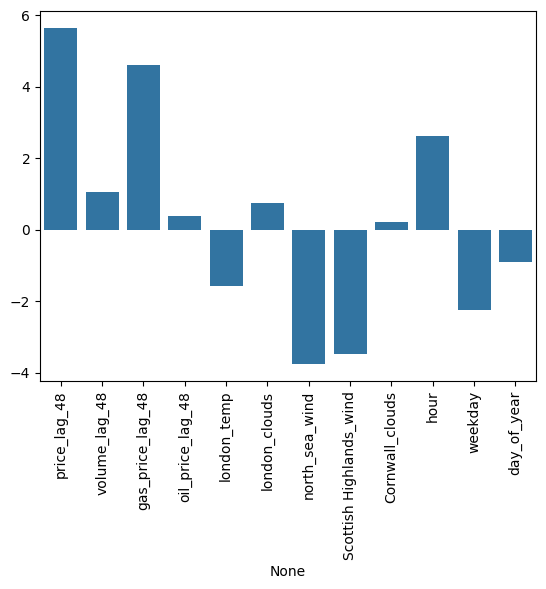

In [122]:
sns.barplot(y=lin_model.coef_, x=X_train.columns)
plt.xticks(rotation=90)

In [127]:
seq_length = int(168*2)
forecast_horizon = int(24*2)  # 24*2
offset = seq_length + forecast_horizon - 1
y_val_lin = y_val.iloc[offset:].reset_index(drop=True)
X_val_lin = X_val_scaled.iloc[seq_length - 1 : -forecast_horizon].reset_index(drop=True)
predictions_lin = lin_model.predict(X_val_lin)

In [128]:
print("Mean Absolute Error (MAE):",  mean_absolute_error(y_val_lin, predictions_lin))
print("RMSE:",  np.sqrt(mean_squared_error(y_val_lin, predictions_lin)))

Mean Absolute Error (MAE): 11.218723903230906
RMSE: 14.672447998564719


In [125]:
y_val_lin

0       39.540
1       39.930
2       40.025
3       41.170
4       39.355
         ...  
5468    27.375
5469    27.030
5470    24.545
5471    26.790
5472    25.235
Name: price, Length: 5473, dtype: float64

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=150, learning_rate=0.05, random_state=42)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_val, y_val)],
    verbose=25
)

# You can then plot the internal history easily
results = xgb_model.evals_result()

[0]	validation_0-rmse:18.51187	validation_1-rmse:15.36325


[25]	validation_0-rmse:12.43941	validation_1-rmse:12.02611
[50]	validation_0-rmse:10.49032	validation_1-rmse:11.60795
[75]	validation_0-rmse:9.51115	validation_1-rmse:11.87423
[100]	validation_0-rmse:9.01700	validation_1-rmse:12.12285
[125]	validation_0-rmse:8.67208	validation_1-rmse:12.13290
[149]	validation_0-rmse:8.37381	validation_1-rmse:12.13251


In [89]:
predictions = xgb_model.predict(X_val)


In [108]:
seq_length = int(168*2)
forecast_horizon = int(24*2)  # 24*2
offset = seq_length + forecast_horizon - 1
y_val_xgb = y_val.iloc[offset:].reset_index(drop=True)
X_val_xgb = X_val.iloc[seq_length - 1 : -forecast_horizon].reset_index(drop=True)
predictions_xgb = xgb_model.predict(X_val_xgb)


In [112]:
print("Mean Absolute Error (MAE):",  mean_absolute_error(y_val_xgb, predictions_xgb))
print("RMSE:",  np.sqrt(mean_squared_error(y_val_xgb, predictions_xgb)))

Mean Absolute Error (MAE): 10.754694999678412
RMSE: 14.524284706425089


<Axes: >

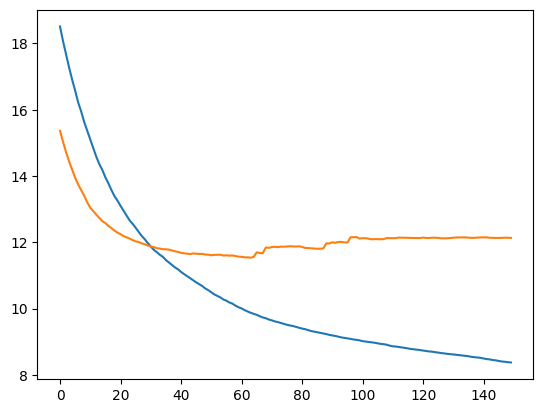

In [90]:
sns.lineplot(results['validation_0']['rmse'])
sns.lineplot(results['validation_1']['rmse'])

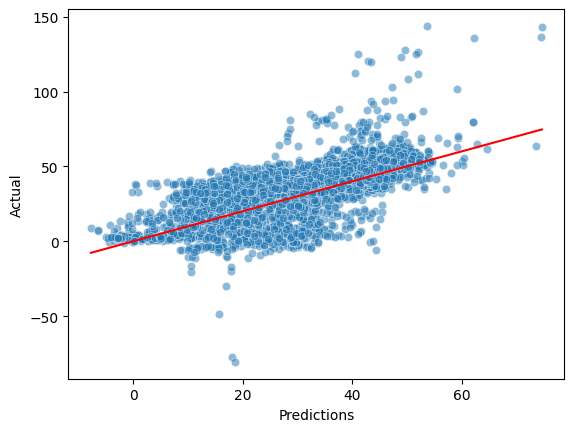

In [48]:
sns.scatterplot(x=predictions,y=y_val,alpha=0.5)
plt.xlabel('Predictions')
plt.ylabel('Actual')
identity_line = np.linspace(max(min(predictions), min(y_val)),
                            min(max(predictions), max(y_val)))
plt.plot(identity_line, identity_line, color='red')

<Axes: xlabel='time', ylabel='price'>

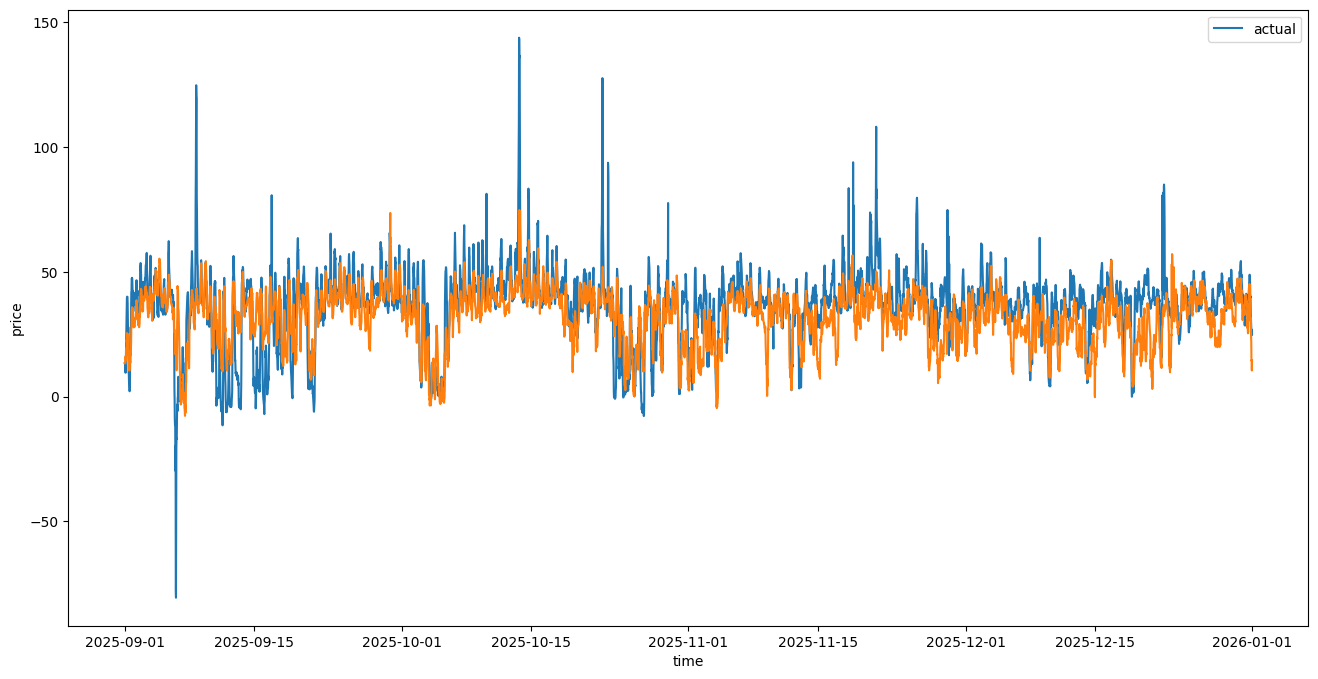

In [41]:
plt.figure(figsize=(16,8))
sns.lineplot(y_val, label='actual')
sns.lineplot(pd.Series(predictions,index=y_val.index))

In [114]:
predictions_xgb

array([16.718542, 28.464706, 30.674492, ..., 37.376976, 32.81147 ,
       34.680435], dtype=float32)

<Axes: ylabel='price'>

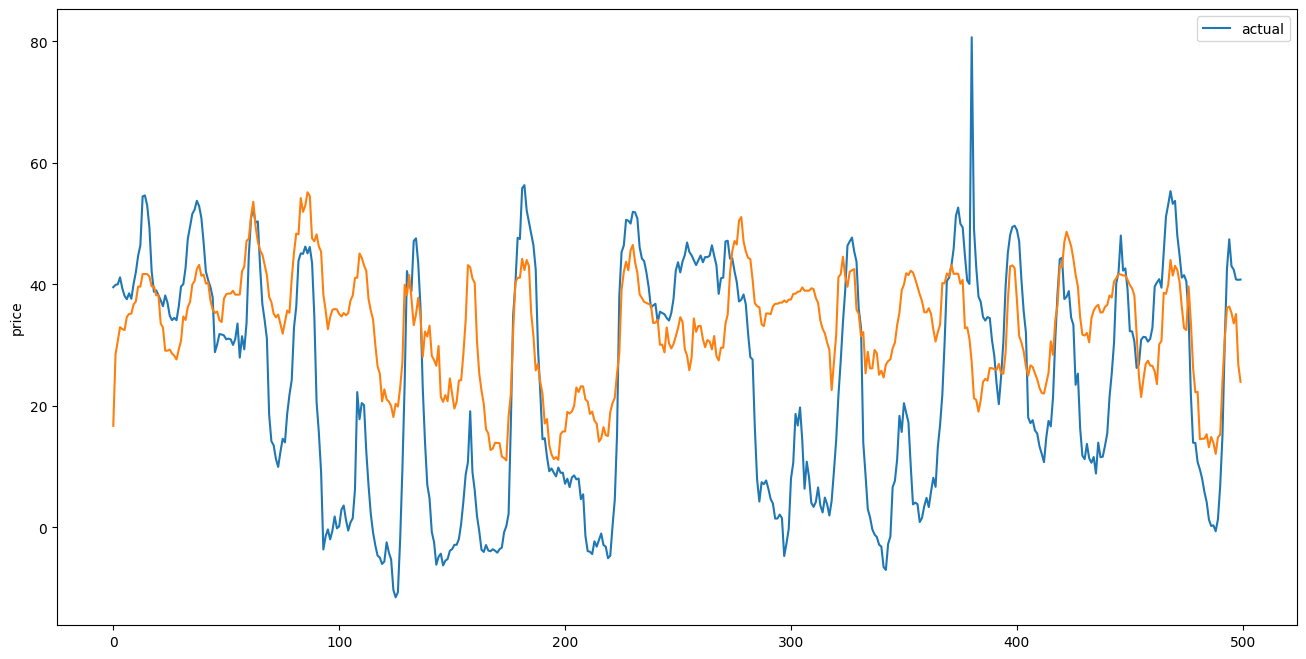

In [116]:
plt.figure(figsize=(16,8))
sns.lineplot(y_val_xgb.iloc[0:500], label='actual')

sns.lineplot(predictions_xgb[0:500])

<Axes: xlabel='time', ylabel='price'>

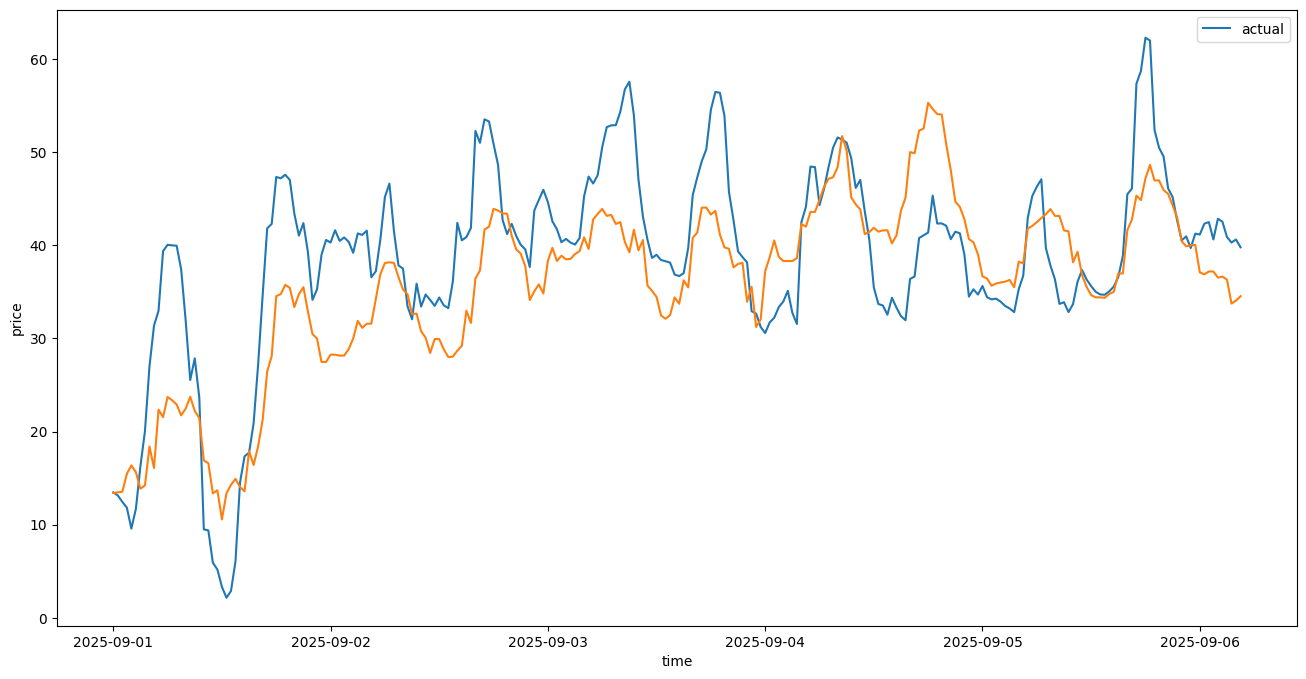

In [ ]:
plt.figure(figsize=(16,8))
sns.lineplot(y_val.iloc[0:250], label='actual')

sns.lineplot(pd.Series(predictions,index=y_val.index).iloc[0:250])

In [99]:
y_val

time
2025-09-01 00:00:00+00:00    13.465
2025-09-01 00:30:00+00:00    13.135
2025-09-01 01:00:00+00:00    12.445
2025-09-01 01:30:00+00:00    11.825
2025-09-01 02:00:00+00:00     9.570
                              ...  
2025-12-31 21:30:00+00:00    27.375
2025-12-31 22:00:00+00:00    27.030
2025-12-31 22:30:00+00:00    24.545
2025-12-31 23:00:00+00:00    26.790
2025-12-31 23:30:00+00:00    25.235
Name: price, Length: 5856, dtype: float64

Text(0.5, 1.0, 'realtive feature importance for xgboost')

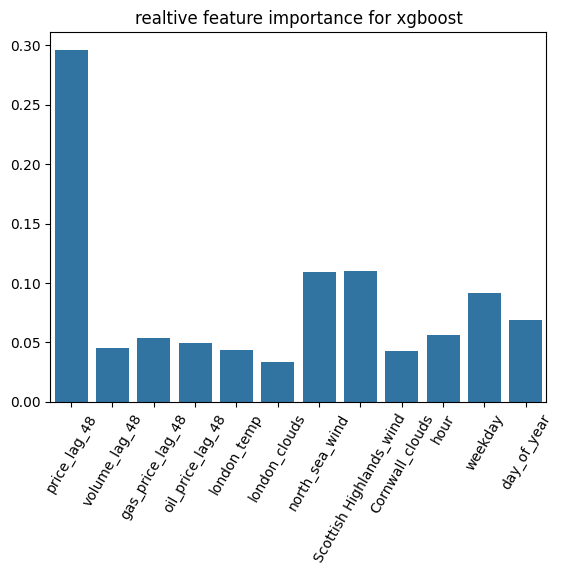

In [133]:
sns.barplot(y=xgb_model.feature_importances_,x=features)
plt.xticks(rotation=60)
plt.title('realtive feature importance for xgboost')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'price_lag_48'),
  Text(1, 0, 'volume_lag_48'),
  Text(2, 0, 'gas_price_lag_48'),
  Text(3, 0, 'oil_price_lag_48'),
  Text(4, 0, 'london_temp'),
  Text(5, 0, 'london_clouds'),
  Text(6, 0, 'north_sea_wind'),
  Text(7, 0, 'Scottish Highlands_wind'),
  Text(8, 0, 'Cornwall_clouds'),
  Text(9, 0, 'hour'),
  Text(10, 0, 'weekday'),
  Text(11, 0, 'day_of_year')])

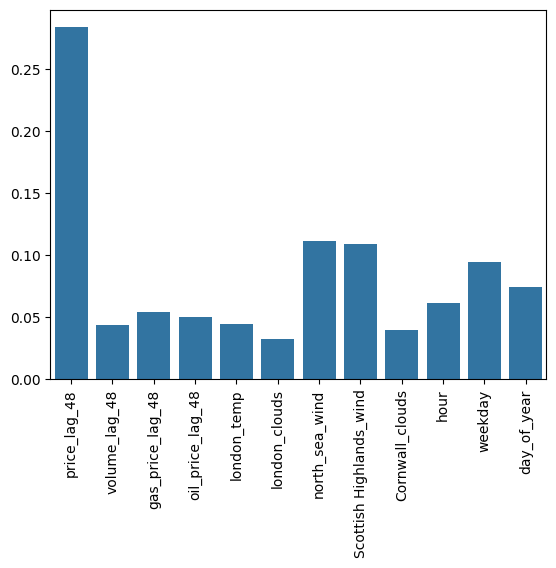

In [42]:
sns.barplot(y=xgb_model.feature_importances_,x=features)
plt.xticks(rotation=90)